# Simple Bot

#### Main Goal: How to integrate LLMs in our Graphs

#### Objectives:
1. Define state structure with a list of HumanMessage objects.
2. Initialize a llm model using LangChain
3. Sending and handling different types of messages
4. Building and compiling the graph of the Agent

In [2]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

## Define Agent State

The `AgentState` is a TypedDict that defines the structure of our agent's state. 

It contains a list of `HumanMessage` objects that will store the conversation history.

In [3]:
class AgentState(TypedDict):
    messages: List[HumanMessage]

### Initialize the LLM Model

Here we initialize a Groq LLM model using:
- API key from environment variables (stored in .env)
- Model: "llama-3.1-8b-instant" (lightweight and fast)
- Temperature: 0 (deterministic responses)

In [4]:
import os

Groq_API_Key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(api_key=Groq_API_Key, model="llama-3.1-8b-instant", temperature=0)

### Define the Processing Node

The `process` function is the core node that:
1. Takes the current state containing messages
2. Invokes the LLM with those messages
3. Prints the AI response
4. Returns the state

In [11]:
def process(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    print(f"\nAI: {response.content}")
    print("-" * 20)
    return state

### Build and Compile the Graph

We create a StateGraph with:
- **START**: Entry point to the graph
- **process**: Our processing node
- **END**: Exit point of the graph

Finally, we compile it into an executable bot.

In [12]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

bot = graph.compile()

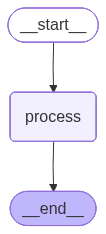

In [13]:
from IPython.display import Image, display
display(Image(bot.get_graph().draw_mermaid_png()))

### Run the Agent

Start an interactive loop where:
- User provides input
- Bot processes and responds
- Loop continues until user types "exit"

In [14]:
user_input = input("Enter: ")
print("==" * 20)
print(f"Human: {user_input}")
while user_input != "exit":
    bot.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")

Human: tell me poor joke

AI: Here's one:

Why couldn't the bicycle stand up by itself?

(wait for it...)

Because it was two-tired!

I know, I know, it's a bit of a "flat" joke.
--------------------

AI: Here's a draft email for requesting sick leave:

Subject: Notification of Sick Leave

Dear [Manager's Name],

I am writing to inform you that I will be unable to come to work for the next [number of days] due to illness. I am currently experiencing [briefly mention the illness or symptoms].

I apologize for any inconvenience this may cause and will make sure to catch up on any missed work as soon as I am able to return. If there are any urgent matters that need my attention in the meantime, please let me know.

I will keep you updated on my status and let you know as soon as I am able to return to work.

Thank you for your understanding and support.

Sincerely,
[Your Name]

Alternatively, you can also use a more concise version:

Subject: Sick Leave Notification

Dear [Manager's Name]